In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)
from sklearn.metrics import roc_curve, auc

In [2]:
df = pd.read_csv("dataset/telco.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [3]:
df.head()

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


In [4]:
print("Rows and Columns:")
print(df.shape)

Rows and Columns:
(7043, 50)


In [5]:
print(df.columns)

Index(['Customer ID', 'Gender', 'Age', 'Under 30', 'Senior Citizen', 'Married',
       'Dependents', 'Number of Dependents', 'Country', 'State', 'City',
       'Zip Code', 'Latitude', 'Longitude', 'Population', 'Quarter',
       'Referred a Friend', 'Number of Referrals', 'Tenure in Months', 'Offer',
       'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Avg Monthly GB Download',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Revenue', 'Satisfaction Score', 'Customer Status', 'Churn Label',
       'Churn Score', 'CLTV', 'Churn Category', 'Churn Reason'],
      dtype='object')


In [6]:
df.isnull().sum()

Customer ID                             0
Gender                                  0
Age                                     0
Under 30                                0
Senior Citizen                          0
Married                                 0
Dependents                              0
Number of Dependents                    0
Country                                 0
State                                   0
City                                    0
Zip Code                                0
Latitude                                0
Longitude                               0
Population                              0
Quarter                                 0
Referred a Friend                       0
Number of Referrals                     0
Tenure in Months                        0
Offer                                3877
Phone Service                           0
Avg Monthly Long Distance Charges       0
Multiple Lines                          0
Internet Service                  

In [7]:
df.dtypes

Customer ID                           object
Gender                                object
Age                                    int64
Under 30                              object
Senior Citizen                        object
Married                               object
Dependents                            object
Number of Dependents                   int64
Country                               object
State                                 object
City                                  object
Zip Code                               int64
Latitude                             float64
Longitude                            float64
Population                             int64
Quarter                               object
Referred a Friend                     object
Number of Referrals                    int64
Tenure in Months                       int64
Offer                                 object
Phone Service                         object
Avg Monthly Long Distance Charges    float64
Multiple L

In [8]:
df["Churn Label"].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

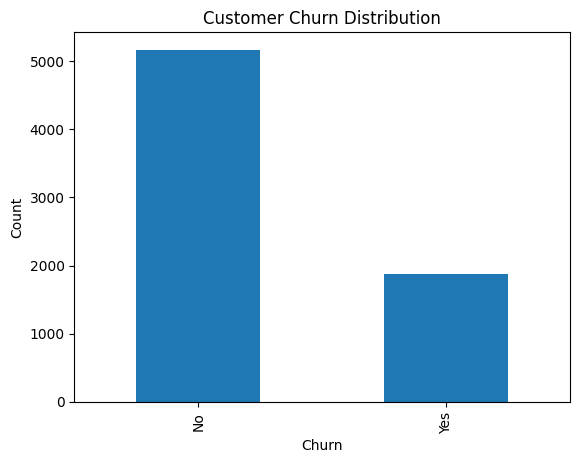

In [9]:
df["Churn Label"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")

plt.show()

In [10]:
df = df.drop(
    [
        "Customer ID",
        "Customer Status",
        "Churn Score",
        "Churn Category",
        "Churn Reason"
    ],
    axis=1
)

print("Columns Removed")

Columns Removed


In [11]:
df["Offer"] = df["Offer"].fillna("No Offer")
df["Internet Type"] = df["Internet Type"].fillna("No Internet")

print("Missing Values Handled")

Missing Values Handled


In [12]:
y = df["Churn Label"]

X = df.drop("Churn Label", axis=1)

print(X.shape)
print(y.shape)

(7043, 44)
(7043,)


In [13]:
le_y = LabelEncoder()
y = le_y.fit_transform(y)

In [14]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

for col in X.columns:
    if X[col].dtype == "object":
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])
        encoders[col] = le

print("Encoding Completed")

Encoding Completed


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (5634, 44)
Testing Shape: (1409, 44)


In [16]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

print("Decision Tree Trained")

Decision Tree Trained


In [17]:
dt_predictions = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_predictions)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.9403832505322924


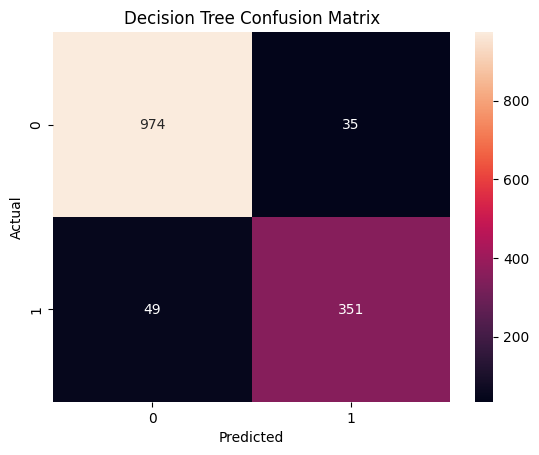

In [18]:
cm = confusion_matrix(y_test, dt_predictions)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [19]:
print(classification_report(y_test, dt_predictions))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96      1009
           1       0.91      0.88      0.89       400

    accuracy                           0.94      1409
   macro avg       0.93      0.92      0.93      1409
weighted avg       0.94      0.94      0.94      1409



In [20]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest Trained")

Random Forest Trained


In [21]:
rf_predictions = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_predictions)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9531582682753726


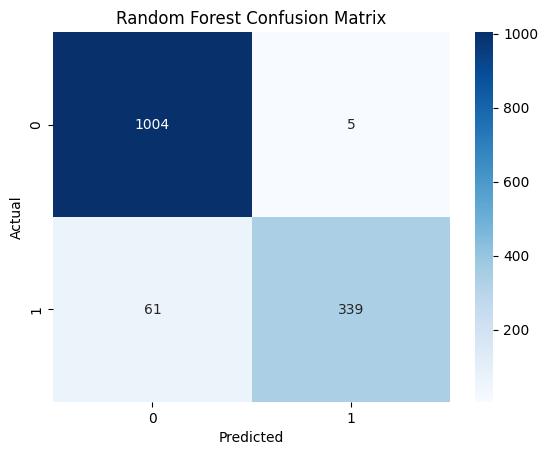

In [22]:
rf_cm = confusion_matrix(y_test, rf_predictions)

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [23]:
print(classification_report(y_test, rf_predictions))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97      1009
           1       0.99      0.85      0.91       400

    accuracy                           0.95      1409
   macro avg       0.96      0.92      0.94      1409
weighted avg       0.95      0.95      0.95      1409



In [24]:
from sklearn.metrics import f1_score

dt_f1 = f1_score(y_test, dt_predictions)
rf_f1 = f1_score(y_test, rf_predictions)

print("Decision Tree F1 Score :", dt_f1)
print("Random Forest F1 Score :", rf_f1)

Decision Tree F1 Score : 0.8931297709923665
Random Forest F1 Score : 0.9112903225806451


In [25]:
print("Decision Tree Accuracy :", dt_accuracy)
print("Random Forest Accuracy :", rf_accuracy)

print("\nDecision Tree F1 Score :", dt_f1)
print("Random Forest F1 Score :", rf_f1)

Decision Tree Accuracy : 0.9403832505322924
Random Forest Accuracy : 0.9531582682753726

Decision Tree F1 Score : 0.8931297709923665
Random Forest F1 Score : 0.9112903225806451


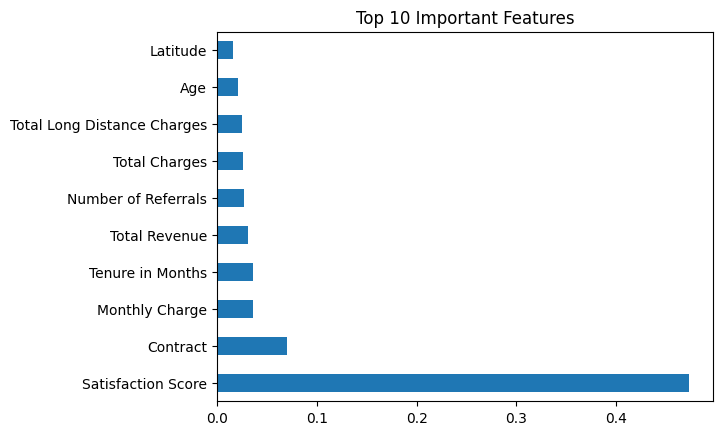

In [26]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)

feature_importance.nlargest(10).plot(kind="barh")

plt.title("Top 10 Important Features")

plt.show()

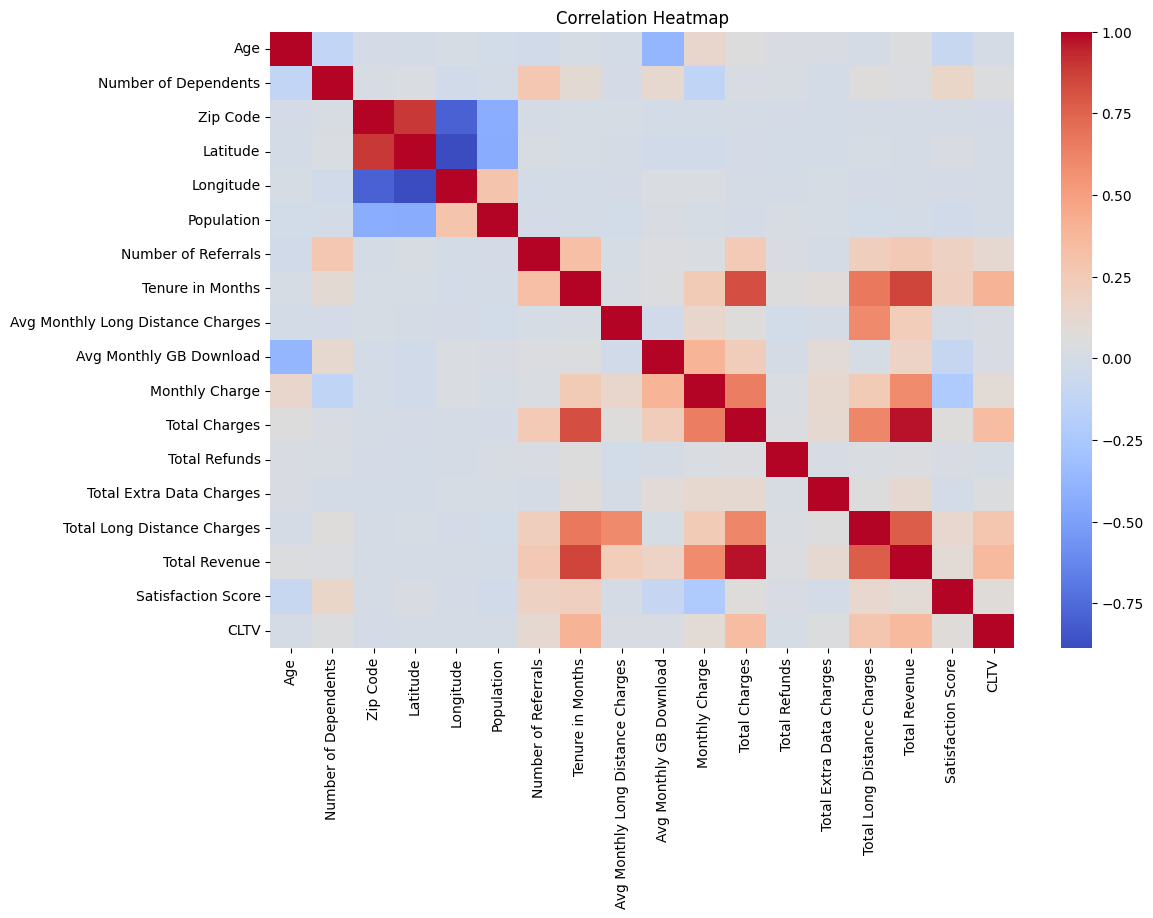

In [27]:
numeric_df = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

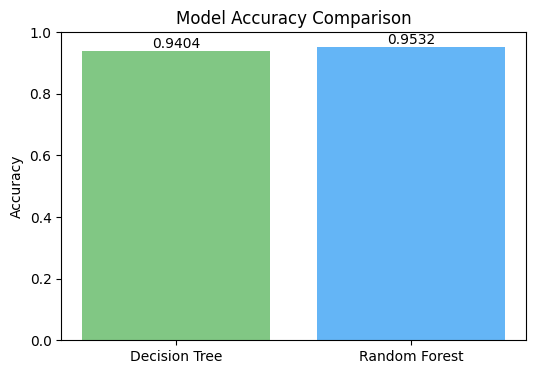

In [28]:
models = ["Decision Tree", "Random Forest"]
accuracies = [dt_accuracy, rf_accuracy]

plt.figure(figsize=(6,4))

bars = plt.bar(
    models,
    accuracies,
    color=["#81C784", "#64B5F6"]
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

# Values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.4f}",
        ha='center',
        va='bottom'
    )

plt.show()

In [29]:
if rf_f1 > dt_f1:
    best_model = "Random Forest"
    best_f1 = rf_f1
else:
    best_model = "Decision Tree"
    best_f1 = dt_f1

print("Best Model Selected:", best_model)
print("Best F1 Score:", best_f1)

Best Model Selected: Random Forest
Best F1 Score: 0.9112903225806451


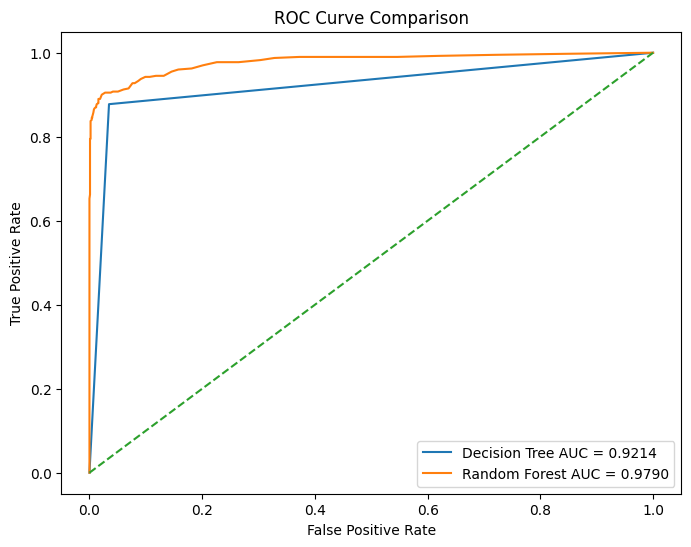

Decision Tree AUC: 0.9214060951437066
Random Forest AUC: 0.979013875123885


In [30]:
# Decision Tree
dt_prob = dt_model.predict_proba(X_test)[:, 1]
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_prob)
roc_auc_dt = auc(fpr_dt, tpr_dt)

# Random Forest
rf_prob = rf_model.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# Plot comparison
plt.figure(figsize=(8,6))

plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree AUC = {roc_auc_dt:.4f}")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest AUC = {roc_auc_rf:.4f}")

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

print("Decision Tree AUC:", roc_auc_dt)
print("Random Forest AUC:", roc_auc_rf)

In [31]:

comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": rf_predictions
})

comparison.head(10)

,Actual,Predicted
0,1,0
1,0,0
2,0,0
3,1,1
4,1,1
5,1,1
6,0,0
7,1,1
8,0,0
9,1,1


In [32]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": rf_predictions
})

comparison["Actual"] = comparison["Actual"].map({
    0: "No",
    1: "Yes"
})

comparison["Predicted"] = comparison["Predicted"].map({
    0: "No",
    1: "Yes"
})

comparison.head(10)

,Actual,Predicted
0,Yes,No
1,No,No
2,No,No
3,Yes,Yes
4,Yes,Yes
5,Yes,Yes
6,No,No
7,Yes,Yes
8,No,No
9,Yes,Yes


In [33]:
correct_predictions = (
    comparison["Actual"]
    ==
    comparison["Predicted"]
).sum()

print("Correct Predictions:", correct_predictions)

print("Total Test Samples:", len(comparison))

Correct Predictions: 1343
Total Test Samples: 1409


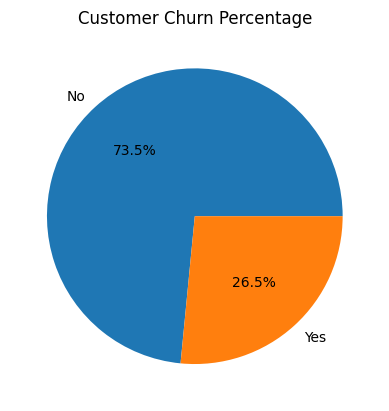

In [34]:
df["Churn Label"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Customer Churn Percentage")
plt.ylabel("")
plt.show()

In [35]:
pd.crosstab(
    df["Contract"],
    df["Churn Label"]
)

Churn Label,No,Yes
Contract,,
Month-to-Month,1955,1655
One Year,1384,166
Two Year,1835,48


In [36]:
import joblib

joblib.dump(
    rf_model,
    "best_churn_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


# FINAL DEPLOYMENT MODEL (Top Features)

In [37]:
from sklearn.preprocessing import LabelEncoder

y = df["Churn Label"].copy()

le_y = LabelEncoder()
y = le_y.fit_transform(y)

In [38]:
top_features = [
    "Satisfaction Score",
    "Contract",
    "Monthly Charge",
    "Tenure in Months",
    "Total Revenue",
    "Number of Referrals",
    "Total Charges",
    "Total Long Distance Charges",
    "Age"
]

print("Deployment Features:")
print(top_features)

Deployment Features:
['Satisfaction Score', 'Contract', 'Monthly Charge', 'Tenure in Months', 'Total Revenue', 'Number of Referrals', 'Total Charges', 'Total Long Distance Charges', 'Age']


In [39]:
print(df.columns.tolist())

['Gender', 'Age', 'Under 30', 'Senior Citizen', 'Married', 'Dependents', 'Number of Dependents', 'Country', 'State', 'City', 'Zip Code', 'Latitude', 'Longitude', 'Population', 'Quarter', 'Referred a Friend', 'Number of Referrals', 'Tenure in Months', 'Offer', 'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines', 'Internet Service', 'Internet Type', 'Avg Monthly GB Download', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Revenue', 'Satisfaction Score', 'Churn Label', 'CLTV']


In [40]:
missing = [col for col in top_features if col not in df.columns]
print("Missing columns:", missing)

Missing columns: []


In [41]:
X_reduced = df[top_features].copy()

In [42]:
# Ensure consistent encoding by using the same Contract encoder from training
X_reduced["Contract"] = encoders["Contract"].transform(X_reduced["Contract"])

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_reduced,
    y,
    test_size=0.2,
    random_state=42
)

In [44]:
from sklearn.ensemble import RandomForestClassifier

final_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

final_model.fit(X_train, y_train)

print("Final Model Trained using Selected Features")

Final Model Trained using Selected Features


In [45]:
from sklearn.metrics import accuracy_score, f1_score

y_pred = final_model.predict(X_test)

print("Final Model Accuracy:", accuracy_score(y_test, y_pred))
print("Final Model F1 Score:", f1_score(y_test, y_pred))

Final Model Accuracy: 0.9446415897799858
Final Model F1 Score: 0.8945945945945946


In [46]:

joblib.dump(encoders, "encoders.pkl")

['encoders.pkl']

In [47]:
import joblib

joblib.dump(final_model, "churn_model_streamlit.pkl")

print("Streamlit Model Saved Successfully")

Streamlit Model Saved Successfully


# Final Conclusion

Two machine learning models were developed and evaluated for customer churn prediction.

## Dataset Used:
Telco Customer Churn Dataset

## Models Used:
1. Decision Tree Classifier  
2. Random Forest Classifier  

## Evaluation Metrics Used:
Accuracy, F1 Score, Confusion Matrix, ROC-AUC

## Results:
- Decision Tree Accuracy: 94.04%  
- Random Forest Accuracy: 95.32%  

## Best Model Selected:
**Random Forest Classifier**

## Saved Models:
- `best_churn_model.pkl` → Full feature Random Forest model  
- `churn_model_streamlit.pkl` → Optimized deployment model with selected features  

## Final Outcome:
The Random Forest model achieved the highest accuracy and was selected as the final model for customer churn prediction.

Feature selection helped reduce model complexity while maintaining strong predictive performance.

## Project Status:
The customer churn prediction system is successfully completed and ready for real-time use.